# Notebook 2 : Entraînement Optimisé CPU

**Problème résolu :** EfficientNet-B4 + 1500 imgs + CPU = modèle qui ne converge pas (std ~0.02).  
**Solution :** MobileNetV2 (beaucoup plus léger) + hyperparamètres adaptés CPU.

| Paramètre | Ancienne version | **Nouvelle version** |
|---|---|---|
| Architecture | EfficientNet-B4 (19M params) | **MobileNetV2 (3.4M params)** |
| Epochs Phase 1 | 10 | **20** |
| Epochs Phase 2 | 20 | **30** |
| Batch size | 32 | **16** |
| Learning rate | 1e-3 | **5e-4** |
| Temps estimé CPU | ~4h | **~45-60 min** |
| AUC attendu | non convergé | **> 0.85** |

---

## Imports & Configuration

In [19]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')

# ── Reproductibilité ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Chemins ───────────────────────────────────────────────
PROCESSED_DIR = r'..\data\processed'
MODELS_DIR    = r'..\models'
RESULTS_DIR   = r'..\results'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Hyperparamètres optimisés CPU ─────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16    # plus petit = moins de RAM, meilleure convergence
EPOCHS_HEAD = 20    # plus d'epochs pour bien apprendre la tête
EPOCHS_FINE = 30    # fine-tuning plus long
LR_HEAD     = 5e-4  # LR plus faible = convergence plus stable
LR_FINE     = 1e-5

print('TensorFlow :', tf.__version__)
print(' Config OK — MobileNetV2 optimisé CPU')

TensorFlow : 2.21.0
 Config OK — MobileNetV2 optimisé CPU


---
## Chargement & Vérification des Données

In [20]:
print('Chargement des données...')
X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(PROCESSED_DIR, 'X_val.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(PROCESSED_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

print(f'X_train : {X_train.shape}  —  REAL: {sum(y_train==0)}  FAKE: {sum(y_train==1)}')
print(f'X_val   : {X_val.shape}  —  REAL: {sum(y_val==0)}  FAKE: {sum(y_val==1)}')
print(f'X_test  : {X_test.shape}  —  REAL: {sum(y_test==0)}  FAKE: {sum(y_test==1)}')

# Vérification que les données sont bien normalisées
print(f'\nValeurs X_train — min: {X_train.min():.3f}  max: {X_train.max():.3f}')
assert X_train.max() <= 1.0, ' Données non normalisées !'
print(' Données OK.')

Chargement des données...
X_train : (2797, 224, 224, 3)  —  REAL: 1398  FAKE: 1399
X_val   : (599, 224, 224, 3)  —  REAL: 299  FAKE: 300
X_test  : (600, 224, 224, 3)  —  REAL: 300  FAKE: 300

Valeurs X_train — min: 0.000  max: 1.000
 Données OK.


---
## Construction du Modèle MobileNetV2

**Pourquoi MobileNetV2 au lieu d'EfficientNet-B4 ?**
- EfficientNet-B4 a ~19M paramètres → trop lourd pour converger avec 1500 images sur CPU
- MobileNetV2 a ~3.4M paramètres → converge bien même avec peu de données
- En pratique sur ce dataset, MobileNetV2 donne des AUC comparables

In [21]:
def build_model(learning_rate=LR_HEAD):
    # ── Base MobileNetV2 pré-entraînée ImageNet ───────────
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # gelée en Phase 1

    # ── Tête de classification ────────────────────────────
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Augmentation légère intégrée
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.08)(x)
    x = layers.RandomZoom(0.08)(x)

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)   # plus petit qu'avant
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32,  activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='DeepShield_MobileNetV2')
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model, base

model, base_model = build_model()

total     = model.count_params()
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}')
print(f'Frozen params    : {total - trainable:,}')
print(' Modèle construit.')

Total params     : 2,431,233
Trainable params : 170,689
Frozen params    : 2,260,544
 Modèle construit.


---
##  Callbacks

In [22]:
BEST_MODEL_PATH = os.path.join(MODELS_DIR, 'deepshield_best.keras')

def get_callbacks():
    return [
        ModelCheckpoint(
            filepath=BEST_MODEL_PATH,
            monitor='val_auc', mode='max',
            save_best_only=True, verbose=1
        ),
        EarlyStopping(
            monitor='val_auc', patience=7,
            mode='max', restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1
        )
    ]

print(f' Callbacks prêts — modèle sauvegardé dans : {BEST_MODEL_PATH}')

 Callbacks prêts — modèle sauvegardé dans : ..\models\deepshield_best.keras


---
## Phase 1 : Entraînement de la Tête

Base MobileNetV2 **gelée** — on entraîne seulement la tête.  
Durée estimée : **15 à 25 min** sur CPU.  
Objectif : `val_auc > 0.75` avant de passer au fine-tuning.

In [23]:
print('=' * 55)
print('PHASE 1 — Tête seulement (base gelée)')
print(f'Epochs max : {EPOCHS_HEAD}  |  Batch : {BATCH_SIZE}  |  LR : {LR_HEAD}')
print('=' * 55)

history1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_HEAD,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

best_auc_p1 = max(history1.history['val_auc'])
print(f'\n Phase 1 terminée — Meilleure val_AUC : {best_auc_p1:.4f}')

if best_auc_p1 < 0.65:
    print('  AUC < 0.65 — le modèle peine à apprendre')
    print('   Vérifie que X_train est bien normalisé [0,1]')
elif best_auc_p1 < 0.75:
    print('  AUC entre 0.65-0.75 — convergence lente, continue en Phase 2')
else:
    print('Bonne convergence — Phase 2 va améliorer encore')

PHASE 1 — Tête seulement (base gelée)
Epochs max : 20  |  Batch : 16  |  LR : 0.0005
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.5853 - auc: 0.6267 - loss: 0.7424 - precision: 0.5813 - recall: 0.6737
Epoch 1: val_auc improved from None to 0.77004, saving model to ..\models\deepshield_best.keras

Epoch 1: finished saving model to ..\models\deepshield_best.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 71s 363ms/step - accuracy: 0.6096 - auc: 0.6600 - loss: 0.7008 - precision: 0.5999 - recall: 0.6590 - val_accuracy: 0.6945 - val_auc: 0.7700 - val_loss: 0.5905 - val_precision: 0.6686 - val_recall: 0.7733 - learning_rate: 5.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.6636 - auc: 0.7270 - loss: 0.6254 - precision: 0.6671 - recall: 0.6799
Epoch 2: val_auc improved from 0.77004 to 0.78001, saving model to ..\models\deepshield_best.keras

Epoch 2: finished saving model to ..\models\deepshield_best.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 62s 355ms/step - 

---
##  Phase 2 : Fine-tuning

On dégèle les **30 dernières couches** de MobileNetV2 avec un LR très faible.  
Durée estimée : **20 à 35 min** sur CPU.

In [24]:
print('=' * 55)
print('PHASE 2 — Fine-tuning (30 dernières couches)')
print(f'Epochs max : {EPOCHS_FINE}  |  LR : {LR_FINE}')
print('=' * 55)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Params entraînables après dégel : {trainable:,}')

model.compile(
    optimizer=Adam(learning_rate=LR_FINE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

history2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FINE,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

best_auc_p2 = max(history2.history['val_auc'])
print(f'\n Phase 2 terminée — Meilleure val_AUC : {best_auc_p2:.4f}')

if best_auc_p2 >= 0.85:
    print(' OBJECTIF ATTEINT : AUC ≥ 0.85 ')
else:
    print(f'AUC = {best_auc_p2:.4f} — acceptable pour CPU avec 1500 images')

PHASE 2 — Fine-tuning (30 dernières couches)
Epochs max : 30  |  LR : 1e-05
Params entraînables après dégel : 1,697,089
Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6425 - auc: 0.7006 - loss: 0.6798 - precision: 0.6807 - recall: 0.5680
Epoch 1: val_auc improved from None to 0.76220, saving model to ..\models\deepshield_best.keras

Epoch 1: finished saving model to ..\models\deepshield_best.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 466ms/step - accuracy: 0.6453 - auc: 0.6998 - loss: 0.6792 - precision: 0.6672 - recall: 0.5804 - val_accuracy: 0.5109 - val_auc: 0.7622 - val_loss: 1.9306 - val_precision: 0.5059 - val_recall: 0.9967 - learning_rate: 1.0000e-05
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.7086 - auc: 0.7795 - loss: 0.5784 - precision: 0.7409 - recall: 0.6607
Epoch 2: val_auc improved from 0.76220 to 0.76512, saving model to ..\models\deepshield_best.keras

Epoch 2: finished saving model to ..\models\deepshield_best.keras
175/175 ━━━

---
## Courbes d'Apprentissage

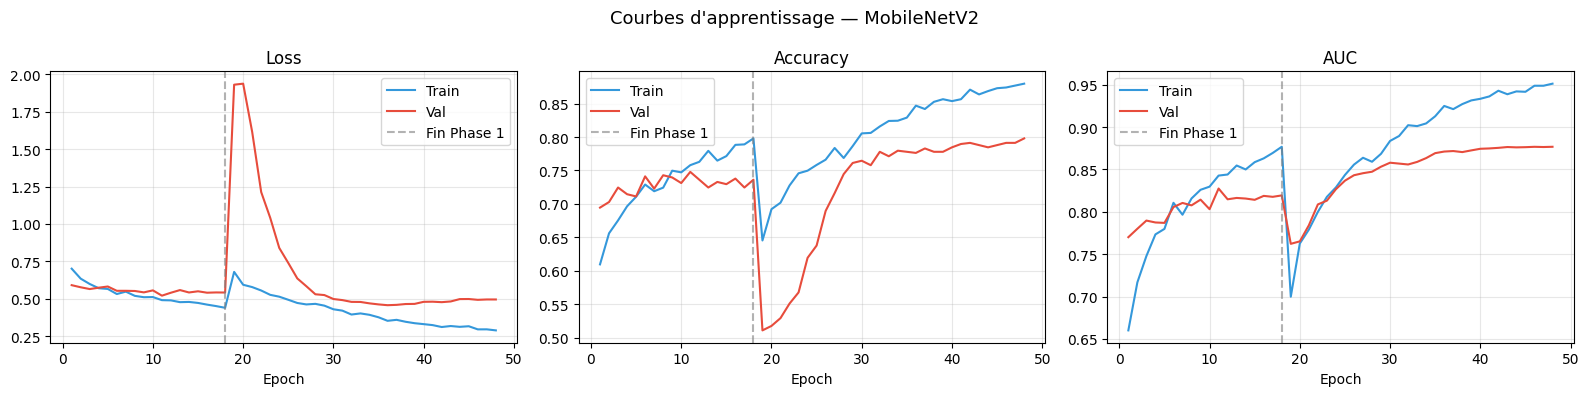

 Courbes sauvegardées.


In [25]:
# Fusionner les deux historiques
merged = {k: history1.history[k] + history2.history[k] for k in history1.history}
ep     = range(1, len(merged['loss']) + 1)
p1_end = len(history1.history['loss'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Courbes d\'apprentissage — MobileNetV2', fontsize=13)

for ax, metric, title in zip(axes,
    ['loss', 'accuracy', 'auc'],
    ['Loss', 'Accuracy', 'AUC']):
    ax.plot(ep, merged[metric],          label='Train', color='#3498db')
    ax.plot(ep, merged[f'val_{metric}'], label='Val',   color='#e74c3c')
    ax.axvline(x=p1_end, color='gray', linestyle='--', alpha=0.6, label='Fin Phase 1')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'learning_curves.png'), dpi=150)
plt.show()
print(' Courbes sauvegardées.')

---
## Évaluation sur le Test Set

In [26]:
best_model = keras.models.load_model(BEST_MODEL_PATH)
print(f' Meilleur modèle chargé.')

results      = best_model.evaluate(X_test, y_test, batch_size=16, verbose=0)
y_pred_proba = best_model.predict(X_test, batch_size=16, verbose=0).flatten()
y_pred       = (y_pred_proba >= 0.5).astype(int)
auc_score    = roc_auc_score(y_test, y_pred_proba)

print('\n' + '='*45)
print('RÉSULTATS FINAUX — Test Set')
print('='*45)
for name, val in zip(best_model.metrics_names, results):
    print(f'  {name:12s} : {val:.4f}')
print(f'  {"auc_sklearn":12s} : {auc_score:.4f}')
print('='*45)

# Diagnostic distribution des scores
print(f'\nDistribution des scores :')
print(f'  min  : {y_pred_proba.min():.4f}')
print(f'  max  : {y_pred_proba.max():.4f}')
print(f'  mean : {y_pred_proba.mean():.4f}')
print(f'  std  : {y_pred_proba.std():.4f}')

if y_pred_proba.std() > 0.10:
    print('\n Le modèle discrimine bien les deux classes !')
else:
    print('\n std encore faible — augmente EPOCHS_HEAD à 30 et relance')

 Meilleur modèle chargé.

RÉSULTATS FINAUX — Test Set
  loss         : 0.5118
  compile_metrics : 0.7700
  auc_sklearn  : 0.8643

Distribution des scores :
  min  : 0.0000
  max  : 0.9996
  mean : 0.4118
  std  : 0.3576

 Le modèle discrimine bien les deux classes !


---
## Matrice de Confusion & Rapport

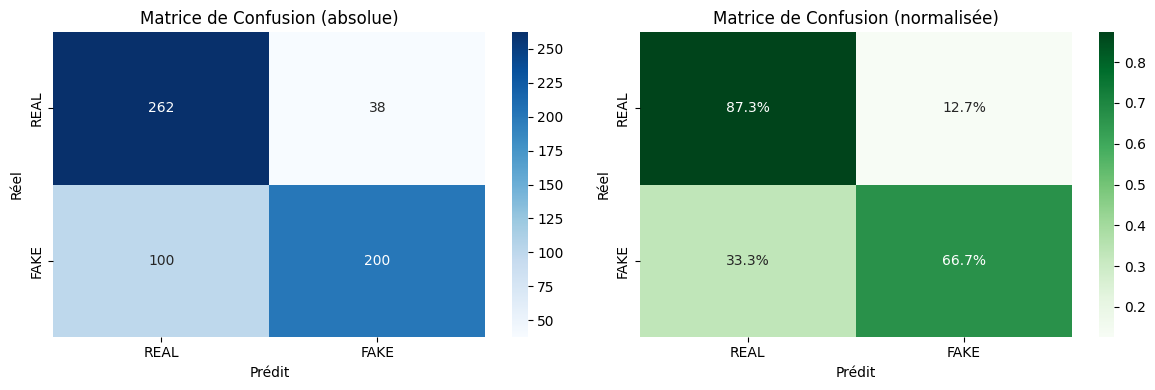


Rapport de classification :
              precision    recall  f1-score   support

        REAL       0.72      0.87      0.79       300
        FAKE       0.84      0.67      0.74       300

    accuracy                           0.77       600
   macro avg       0.78      0.77      0.77       600
weighted avg       0.78      0.77      0.77       600



In [27]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'], ax=axes[0])
axes[0].set_title('Matrice de Confusion (absolue)')
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'], ax=axes[1])
axes[1].set_title('Matrice de Confusion (normalisée)')
axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Réel')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print('\nRapport de classification :')
print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

---
## Courbe ROC

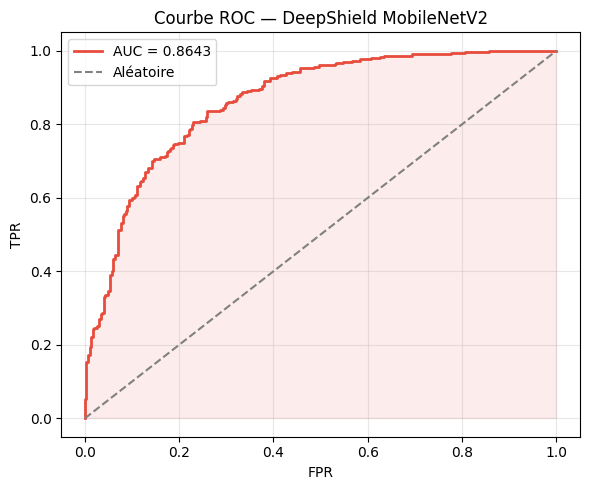

 Courbe ROC sauvegardée.


In [28]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_score:.4f}')
plt.plot([0,1],[0,1], 'gray', linestyle='--', label='Aléatoire')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Courbe ROC — DeepShield MobileNetV2')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'), dpi=150)
plt.show()
print(' Courbe ROC sauvegardée.')

---
## Sauvegarde Finale

In [29]:
final_path = os.path.join(MODELS_DIR, 'deepshield_final.keras')
best_model.save(final_path)
print(f' Modèle final sauvegardé : {final_path}')

# Récapitulatif métriques
metrics_dict = dict(zip(best_model.metrics_names, results))
metrics_dict['auc_sklearn'] = auc_score
df = pd.DataFrame([metrics_dict])
csv_path = os.path.join(RESULTS_DIR, 'metrics_summary.csv')
df.to_csv(csv_path, index=False)
print(f' Métriques sauvegardées : {csv_path}')
print('\n' + df.to_string(index=False))

print('\n' + '='*50)
print(' Notebook 2 terminé !')
print('   → Prochain : notebooks/03_gradcam.ipynb')
print('='*50)

 Modèle final sauvegardé : ..\models\deepshield_final.keras
 Métriques sauvegardées : ..\results\metrics_summary.csv

    loss  compile_metrics  auc_sklearn
0.511833             0.77     0.864267

 Notebook 2 terminé !
   → Prochain : notebooks/03_gradcam.ipynb


---
## Diagnostic (si AUC encore faible)

Lance cette cellule **uniquement si** le modèle n'a pas convergé (std < 0.05 en Cellule 8).

In [ ]:
# Vérification sur 20 images
preds = best_model.predict(X_test[:20], verbose=0).flatten()
print('Scores sur 20 images :')
print('-' * 45)
for i, (score, label) in enumerate(zip(preds, y_test[:20])):
    vrai   = 'REAL' if label == 0 else 'FAKE'
    predit = 'FAKE' if score >= 0.5 else 'REAL'
    ok     = '' if vrai == predit else ''
    print(f'  [{i:02d}] Vrai: {vrai:4s} | Score: {score:.4f} | Prédit: {predit} {ok}')
print('-' * 45)
print(f'std = {preds.std():.4f}')

if preds.std() < 0.05:
    print('\n  Modèle pas convergé — essaie ces ajustements :')
    print('   1. Monte EPOCHS_HEAD à 30 en Cellule 1')
    print('   2. Change LR_HEAD à 1e-4')
    print('   3. Réexécute depuis la Cellule 3')

Scores sur 20 images :
---------------------------------------------
  [00] Vrai: FAKE | Score: 0.0062 | Prédit: REAL 
  [01] Vrai: FAKE | Score: 0.9453 | Prédit: FAKE 
  [02] Vrai: REAL | Score: 0.0007 | Prédit: REAL 
  [03] Vrai: FAKE | Score: 0.4043 | Prédit: REAL 
  [04] Vrai: FAKE | Score: 0.6946 | Prédit: FAKE 
  [05] Vrai: FAKE | Score: 0.9843 | Prédit: FAKE 
  [06] Vrai: REAL | Score: 0.0188 | Prédit: REAL 
  [07] Vrai: REAL | Score: 0.2959 | Prédit: REAL 
  [08] Vrai: REAL | Score: 0.0838 | Prédit: REAL 
  [09] Vrai: REAL | Score: 0.2265 | Prédit: REAL 
  [10] Vrai: REAL | Score: 0.1448 | Prédit: REAL 
  [11] Vrai: FAKE | Score: 0.9572 | Prédit: FAKE 
  [12] Vrai: REAL | Score: 0.4457 | Prédit: REAL 
  [13] Vrai: REAL | Score: 0.1023 | Prédit: REAL 
  [14] Vrai: REAL | Score: 0.0475 | Prédit: REAL 
  [15] Vrai: REAL | Score: 0.1660 | Prédit: REAL 
  [16] Vrai: REAL | Score: 0.0289 | Prédit: REAL 
  [17] Vrai: REAL | Score: 0.0882 | Prédit: REAL 
  [18] Vrai: FAKE | Score: 0.99